# スイング反応器シミュレーター — 包括的テスト

| セクション | 内容 |
|---|---|
| 1. ランダム 100 ケース | 物理的に妥当な範囲でサンプリングしたシミュレーション（物理・コスト指標） |
| 2. 物理整合性チェック | 断熱エネルギー収支・成分収支・各指標範囲の一貫性確認 |
| 3. コスト計算検証 | Bare Module Cost 法の計算ステップを独立検証 |
| 4. エラーハンドリング検証 | 異常入力に対して正しくペナルティが返ることを確認 |

| パラメータ | サンプリング範囲 |
|---|---|
| `T_in`       | 500〜700 °C (773〜973 K) |
| `z_cat`      | 1〜12 m |
| `t_cyc`      | 3〜30 min |
| `D`          | 0.5〜4 m |
| `F_in[C3H8]` | 50〜200 kmol/h |
| `T_feed`     | 25〜127 °C (298〜400 K) |
| `P_in`       | 0.8〜2.5 bar |

In [1]:
import os, sys, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from units.reactors.swing import (
    DesignVars, FeedStream, FixedParams, simulate_swing_reactor_system,
)
from src.cost_calculator import calc_cp0, calc_fp
from src.cost_parameters import (
    K1, K2, K3, B1, B2, FM,
    CEPCI_BASE, CEPCI_CURRENT, K_SWING,
    USD_TO_JPY, PLANT_INDIRECT_FACTOR, DEPRECIATION_YEARS,
)

PASS_STR = 'PASS'
FAIL_STR = 'FAIL'

In [2]:
N   = 100
rng = np.random.default_rng(42)

T_in_arr   = rng.uniform(773.15, 973.15, N)
z_cat_arr  = rng.uniform(  1.0,  12.0,  N)
t_cyc_arr  = rng.uniform(  3.0,  30.0,  N)
D_arr      = rng.uniform(  0.5,   4.0,  N)
F_A_arr    = rng.uniform( 50.0, 200.0,  N)
T_feed_arr = rng.uniform(298.15, 400.0, N)
P_in_arr   = rng.uniform(0.8e5, 2.5e5,  N)

fixed   = FixedParams()
results = []

for i in range(N):
    design = DesignVars(
        T_in  = float(T_in_arr[i]),
        z_cat = float(z_cat_arr[i]),
        t_cyc = float(t_cyc_arr[i]),
        D     = float(D_arr[i]),
    )
    feed = FeedStream(
        F_in  = {'C3H8': float(F_A_arr[i]),
                 'C3H6': 0.0, 'H2': 0.0, 'C2H4': 0.0, 'CH4': 0.0, 'C2H6': 0.0},
        T_feed = float(T_feed_arr[i]),
        P_in   = float(P_in_arr[i]),
    )

    status = 'ok'
    conv = sel = t_out = q_ph = capex = tac = np.nan
    n_react = n_par = n_sw = v_ves = cat_kg = np.nan
    f_c3h8_out = f_c3h6_out = np.nan
    error_msg = ''

    try:
        r = simulate_swing_reactor_system(design, feed, fixed)
        conv       = r.performance.Conversion
        sel        = r.performance.Selectivity
        t_out      = r.effluent.T_out_avg
        q_ph       = r.effluent.Q_preheat
        capex      = r.equipment.Reactor_CAPEX
        tac        = r.TAC
        n_react    = r.equipment.N_reactors_total
        n_par      = r.equipment.N_parallel
        n_sw       = r.equipment.N_swing_sets
        v_ves      = r.equipment.V_vessel_actual
        cat_kg     = r.equipment.Catalyst_Weight_Total
        f_c3h8_out = r.effluent.F_out_avg['C3H8']
        f_c3h6_out = r.effluent.F_out_avg['C3H6']
        if capex >= 1e8:
            status = 'penalty'
    except Exception as e:
        status    = 'error'
        error_msg = f'{type(e).__name__}: {e}'

    results.append({
        'i'          : i,
        'T_in_C'     : T_in_arr[i]  - 273.15,
        'z_cat'      : z_cat_arr[i],
        't_cyc'      : t_cyc_arr[i],
        'D'          : D_arr[i],
        'F_A_in'     : F_A_arr[i],
        'T_feed_C'   : T_feed_arr[i] - 273.15,
        'P_in_bar'   : P_in_arr[i] / 1e5,
        'status'     : status,
        'Conversion' : conv,
        'Selectivity': sel,
        'T_out_C'    : (t_out - 273.15) if not np.isnan(t_out) else np.nan,
        'Q_preheat'  : q_ph,
        'CAPEX'      : capex,
        'TAC'        : tac,
        'N_reactors' : n_react,
        'N_parallel' : n_par,
        'N_swing'    : n_sw,
        'V_vessel'   : v_ves,
        'Cat_kg'     : cat_kg,
        'F_C3H8_out' : f_c3h8_out,
        'F_C3H6_out' : f_c3h6_out,
        'error_msg'  : error_msg,
    })

    if (i + 1) % 10 == 0:
        print(f'{i+1:3d}/100 complete')

df    = pd.DataFrame(results)
df_ok = df[df['status'] == 'ok'].copy()
print(f'\nDone  ok:{len(df_ok)}  penalty:{(df["status"]=="penalty").sum()}  error:{(df["status"]=="error").sum()}')

 10/100 complete
 20/100 complete
 30/100 complete
 40/100 complete
 50/100 complete
 60/100 complete
 70/100 complete
 80/100 complete
 90/100 complete
100/100 complete

Done  ok:100  penalty:0  error:0


In [3]:
print('=== Status count ===')
print(df['status'].value_counts().to_string())
print()
print(f'=== Physical metrics ({len(df_ok)} ok cases) ===')
print(df_ok[['Conversion','Selectivity','T_out_C','Q_preheat']].describe().round(2).to_string())
print()
print(f'=== Cost metrics ({len(df_ok)} ok cases) ===')
print(df_ok[['CAPEX','TAC','V_vessel','N_reactors','Cat_kg']].describe().round(4).to_string())

df_err = df[df['status'] == 'error']
if len(df_err) > 0:
    print()
    print('=== Error cases ===')
    print(df_err[['i','T_in_C','z_cat','t_cyc','D','error_msg']].to_string())

=== Status count ===
status
ok    100

=== Physical metrics (100 ok cases) ===
       Conversion  Selectivity  T_out_C  Q_preheat
count      100.00       100.00   100.00     100.00
mean        19.45        81.35   495.41       8.31
std         10.76        11.80    30.32       3.16
min          4.29        53.61   440.09       2.69
25%         10.86        73.28   472.18       5.33
50%         17.23        82.69   495.47       8.26
75%         23.65        92.30   517.30      10.82
max         58.94        98.91   578.76      14.78

=== Cost metrics (100 ok cases) ===
          CAPEX       TAC  V_vessel  N_reactors       Cat_kg
count  100.0000  100.0000  100.0000    100.0000     100.0000
mean     0.6185    0.0773   32.2896      4.4300   30672.0057
std      0.5774    0.0722   28.4923      1.9605   37322.6324
min      0.0585    0.0073    0.6222      3.0000     373.3038
25%      0.2309    0.0289   10.1883      3.0000    7145.0748
50%      0.4607    0.0576   23.5054      3.0000   18583.426

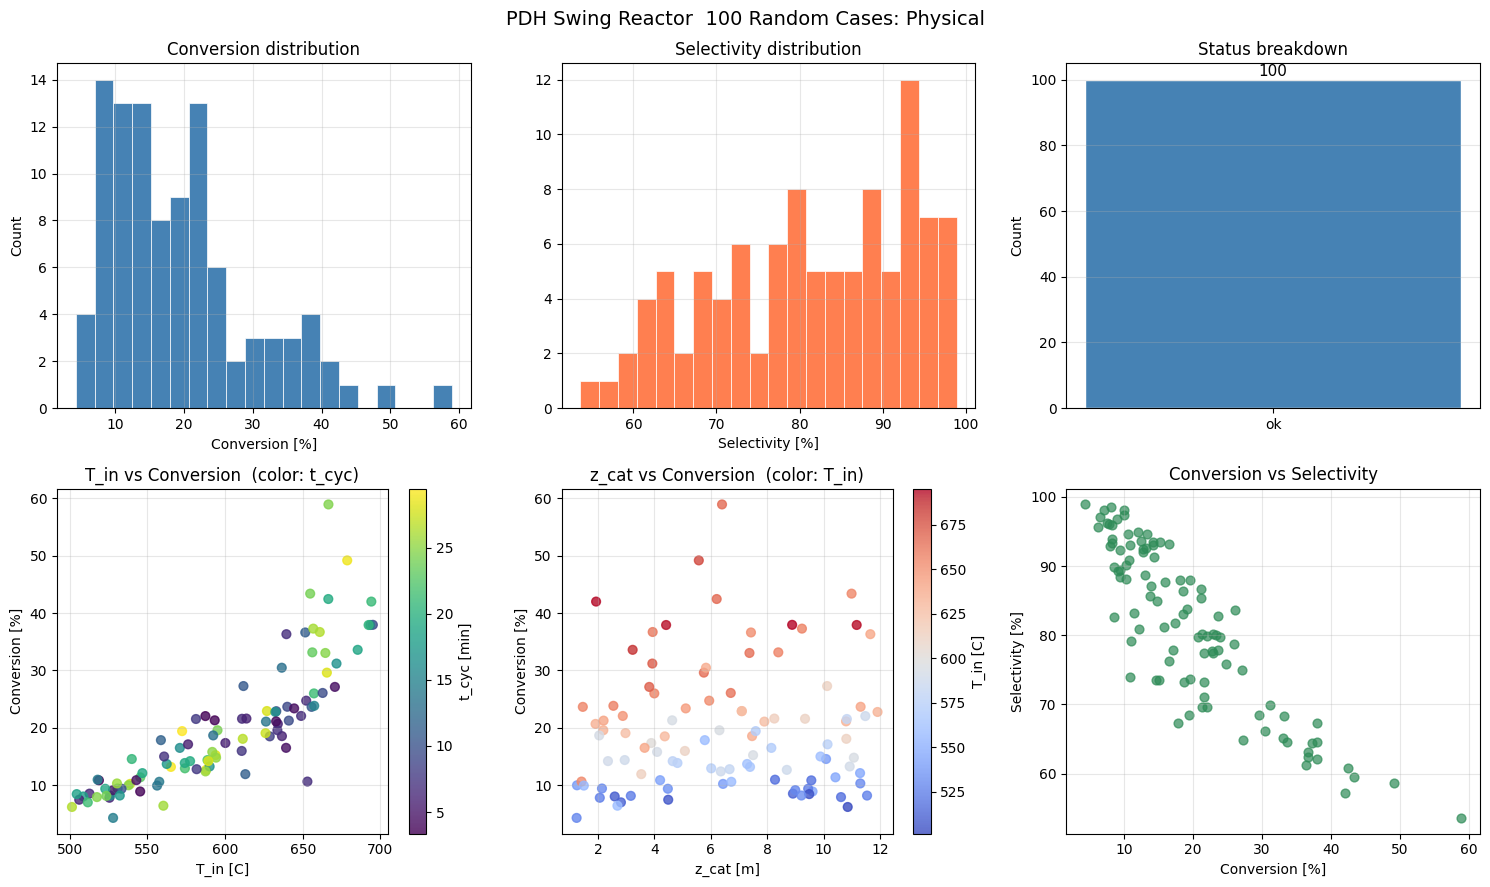

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('PDH Swing Reactor  100 Random Cases: Physical', fontsize=14)
STATUS_COLORS = {'ok': 'steelblue', 'penalty': 'orange', 'error': 'crimson'}

axes[0,0].hist(df_ok['Conversion'].dropna(), bins=20, color='steelblue', edgecolor='white', lw=0.5)
axes[0,0].set_xlabel('Conversion [%]'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Conversion distribution'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df_ok['Selectivity'].dropna(), bins=20, color='coral', edgecolor='white', lw=0.5)
axes[0,1].set_xlabel('Selectivity [%]')
axes[0,1].set_title('Selectivity distribution'); axes[0,1].grid(True, alpha=0.3)

sc = df['status'].value_counts()
bars = axes[0,2].bar(sc.index, sc.values,
                     color=[STATUS_COLORS.get(s,'gray') for s in sc.index], edgecolor='white')
for bar, val in zip(bars, sc.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   str(val), ha='center', va='bottom', fontsize=11)
axes[0,2].set_title('Status breakdown'); axes[0,2].set_ylabel('Count')
axes[0,2].grid(True, alpha=0.3, axis='y')

sc0 = axes[1,0].scatter(df_ok['T_in_C'], df_ok['Conversion'],
                         c=df_ok['t_cyc'], cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc0, ax=axes[1,0], label='t_cyc [min]')
axes[1,0].set_xlabel('T_in [C]'); axes[1,0].set_ylabel('Conversion [%]')
axes[1,0].set_title('T_in vs Conversion  (color: t_cyc)'); axes[1,0].grid(True, alpha=0.3)

sc1 = axes[1,1].scatter(df_ok['z_cat'], df_ok['Conversion'],
                         c=df_ok['T_in_C'], cmap='coolwarm', s=40, alpha=0.8)
plt.colorbar(sc1, ax=axes[1,1], label='T_in [C]')
axes[1,1].set_xlabel('z_cat [m]'); axes[1,1].set_ylabel('Conversion [%]')
axes[1,1].set_title('z_cat vs Conversion  (color: T_in)'); axes[1,1].grid(True, alpha=0.3)

axes[1,2].scatter(df_ok['Conversion'], df_ok['Selectivity'],
                  alpha=0.7, color='seagreen', s=40)
axes[1,2].set_xlabel('Conversion [%]'); axes[1,2].set_ylabel('Selectivity [%]')
axes[1,2].set_title('Conversion vs Selectivity'); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

C:\Users\5koza\AppData\Local\Temp\ipykernel_11428\3329327305.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(n_vals))


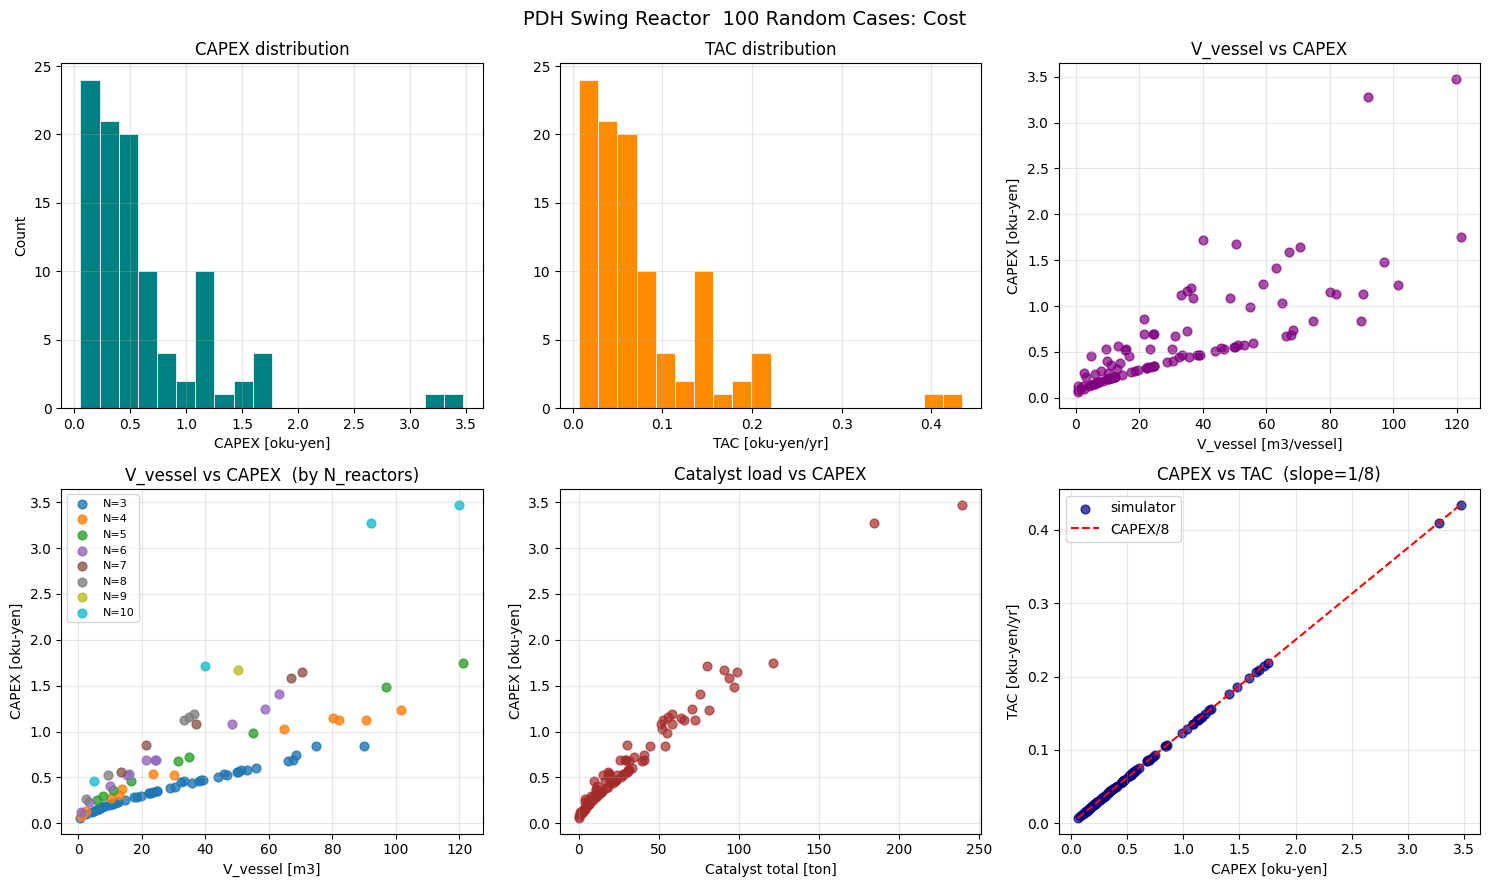

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('PDH Swing Reactor  100 Random Cases: Cost', fontsize=14)

axes[0,0].hist(df_ok['CAPEX'].dropna(), bins=20, color='teal', edgecolor='white', lw=0.5)
axes[0,0].set_xlabel('CAPEX [oku-yen]'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('CAPEX distribution'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df_ok['TAC'].dropna(), bins=20, color='darkorange', edgecolor='white', lw=0.5)
axes[0,1].set_xlabel('TAC [oku-yen/yr]')
axes[0,1].set_title('TAC distribution'); axes[0,1].grid(True, alpha=0.3)

axes[0,2].scatter(df_ok['V_vessel'], df_ok['CAPEX'], alpha=0.7, color='purple', s=40)
axes[0,2].set_xlabel('V_vessel [m3/vessel]'); axes[0,2].set_ylabel('CAPEX [oku-yen]')
axes[0,2].set_title('V_vessel vs CAPEX'); axes[0,2].grid(True, alpha=0.3)

n_vals = sorted(df_ok['N_reactors'].dropna().unique())
cmap   = plt.cm.get_cmap('tab10', len(n_vals))
for idx, n in enumerate(n_vals):
    sub = df_ok[df_ok['N_reactors'] == n]
    axes[1,0].scatter(sub['V_vessel'], sub['CAPEX'], s=40, alpha=0.8,
                      color=cmap(idx), label=f'N={int(n)}')
axes[1,0].set_xlabel('V_vessel [m3]'); axes[1,0].set_ylabel('CAPEX [oku-yen]')
axes[1,0].set_title('V_vessel vs CAPEX  (by N_reactors)')
axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(df_ok['Cat_kg']/1000, df_ok['CAPEX'], alpha=0.7, color='brown', s=40)
axes[1,1].set_xlabel('Catalyst total [ton]'); axes[1,1].set_ylabel('CAPEX [oku-yen]')
axes[1,1].set_title('Catalyst load vs CAPEX'); axes[1,1].grid(True, alpha=0.3)

capex_rng = np.linspace(df_ok['CAPEX'].min(), df_ok['CAPEX'].max(), 50)
axes[1,2].scatter(df_ok['CAPEX'], df_ok['TAC'], alpha=0.7, color='navy', s=40, label='simulator')
axes[1,2].plot(capex_rng, capex_rng / DEPRECIATION_YEARS, 'r--', lw=1.5, label=f'CAPEX/{DEPRECIATION_YEARS}')
axes[1,2].set_xlabel('CAPEX [oku-yen]'); axes[1,2].set_ylabel('TAC [oku-yen/yr]')
axes[1,2].set_title(f'CAPEX vs TAC  (slope=1/{DEPRECIATION_YEARS})')
axes[1,2].legend(); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Section 2 — Physical Consistency Checks

Conditions that must always hold for physically valid results.

In [6]:
checks = []

def chk(label, series_bool, note=''):
    passed = bool(series_bool.all())
    n_fail = int((~series_bool).sum())
    checks.append({'Test': label,
                   'Result': PASS_STR if passed else FAIL_STR,
                   'Failures': 0 if passed else n_fail,
                   'Note': note})
    return passed

# 1. T_out < T_in: endothermic PDH + adiabatic wall => temperature always drops
chk('T_out < T_in',
    df_ok['T_out_C'] < df_ok['T_in_C'],
    'endothermic + adiabatic => T must decrease')

# 2. Conversion in [0, 100]
chk('0 <= Conversion <= 100',
    df_ok['Conversion'].between(0.0, 100.0),
    'clipped by np.clip in simulator')

# 3. Selectivity in [0, 100]
chk('0 <= Selectivity <= 100',
    df_ok['Selectivity'].between(0.0, 100.0),
    'clipped by np.clip in simulator')

# 4. Q_preheat > 0 (T_in > T_feed always in this sampling range)
chk('Q_preheat > 0',
    df_ok['Q_preheat'] > 0.0,
    'T_in > T_feed => heating required')

# 5. F_C3H8_out < F_C3H8_in (propane is consumed)
chk('F_C3H8_out < F_C3H8_in',
    df_ok['F_C3H8_out'] < df_ok['F_A_in'],
    'reactant is always consumed')

# 6. F_C3H6_out >= 0 (molar flow is non-negative)
chk('F_C3H6_out >= 0',
    df_ok['F_C3H6_out'] >= 0.0,
    'negative molar flow is unphysical')

# 7. Conversion > 0 (reaction always occurs with active catalyst)
chk('Conversion > 0',
    df_ok['Conversion'] > 0.0,
    'z_cat > 0 with active catalyst => reaction must occur')

# 8. CAPEX > 0
chk('CAPEX > 0',
    df_ok['CAPEX'] > 0.0,
    'cost of valid vessel is always positive')

# 9. TAC = CAPEX / DEPRECIATION_YEARS (formula consistency)
_tol = 1e-9
chk(f'TAC == CAPEX / {DEPRECIATION_YEARS}',
    (df_ok['TAC'] - df_ok['CAPEX'] / DEPRECIATION_YEARS).abs() < _tol,
    f'exact formula, tol={_tol}')

df_checks = pd.DataFrame(checks)
print(df_checks.to_string(index=False))
n_phys_fail = (df_checks['Result'] == FAIL_STR).sum()
print()
print(f'==> {len(checks) - n_phys_fail}/{len(checks)} checks PASS')

                   Test Result  Failures                                                  Note
           T_out < T_in   PASS         0            endothermic + adiabatic => T must decrease
 0 <= Conversion <= 100   PASS         0                       clipped by np.clip in simulator
0 <= Selectivity <= 100   PASS         0                       clipped by np.clip in simulator
          Q_preheat > 0   PASS         0                     T_in > T_feed => heating required
 F_C3H8_out < F_C3H8_in   PASS         0                           reactant is always consumed
        F_C3H6_out >= 0   PASS         0                     negative molar flow is unphysical
         Conversion > 0   PASS         0 z_cat > 0 with active catalyst => reaction must occur
              CAPEX > 0   PASS         0               cost of valid vessel is always positive
       TAC == CAPEX / 8   PASS         0                              exact formula, tol=1e-09

==> 9/9 checks PASS


---
## Section 3 — Cost Formula Verification

Step-by-step independent recalculation of Bare Module Cost,  
compared against the simulator output for one case.

In [7]:
row       = df_ok.iloc[0]
i_idx     = int(row['i'])
V_ves     = row['V_vessel']
P_pa      = float(P_in_arr[i_idx])
D         = float(D_arr[i_idx])
N_tot     = int(row['N_reactors'])
capex_sim = row['CAPEX']

print(f'Case: i={i_idx}')
print(f'  V_vessel   = {V_ves:.4f} m3')
print(f'  P_in       = {P_pa/1e5:.4f} bar abs')
print(f'  D          = {D:.4f} m')
print(f'  N_reactors = {N_tot}')
print()

P_g        = P_pa / 1e5 - 1.01325
cp0        = calc_cp0(V_ves)
fp         = calc_fp(P_g, D)
fbm        = B1 + B2 * fp * FM
cbm        = cp0 * fbm * K_SWING
cur_usd    = cbm * (CEPCI_CURRENT / CEPCI_BASE)
c_tm_usd   = PLANT_INDIRECT_FACTOR * cur_usd * N_tot
capex_calc = c_tm_usd * USD_TO_JPY / 1e8

print('--- Step-by-step ---')
print(f'  log10(V)           = {math.log10(V_ves):.6f}')
print(f'  Cp0                = {cp0:>12,.1f} USD   (K1={K1}, K2={K2}, K3={K3})')
print(f'  P_gauge            = {P_g:.4f} bar')
print(f'  Fp                 = {fp:.6f}')
print(f'  FBM (B1+B2*Fp*FM)  = {fbm:.6f}   (B1={B1}, B2={B2}, FM={FM})')
print(f'  CBM (x K_swing)    = {cbm:>12,.1f} USD   (K_swing={K_SWING})')
print(f'  Current cost       = {cur_usd:>12,.1f} USD   (CEPCI {CEPCI_CURRENT}/{CEPCI_BASE})')
print(f'  C_TM (x{PLANT_INDIRECT_FACTOR}xN)   = {c_tm_usd:>12,.1f} USD   (N={N_tot})')
print(f'  C_TM               = {capex_calc:.6f} oku-yen  (x{USD_TO_JPY} JPY/USD / 1e8)')
print()
print('--- Comparison ---')
print(f'  Simulator : {capex_sim:.8f} oku-yen')
print(f'  Calculated: {capex_calc:.8f} oku-yen')
err_cost = abs(capex_sim - capex_calc)
print(f'  Abs error : {err_cost:.2e} oku-yen  =>  {PASS_STR if err_cost < 1e-9 else FAIL_STR}')

Case: i=0
  V_vessel   = 89.8920 m3
  P_in       = 1.6118 bar abs
  D          = 3.2265 m
  N_reactors = 3

--- Step-by-step ---
  log10(V)           = 1.953721
  Cp0                =     43,618.0 USD   (K1=3.5565, K2=0.3776, K3=0.0905)
  P_gauge            = 0.5985 bar
  Fp                 = 1.000000
  FBM (B1+B2*Fp*FM)  = 3.010000   (B1=1.49, B2=1.52, FM=1.0)
  CBM (x K_swing)    =    157,548.2 USD   (K_swing=1.2)
  Current cost       =    215,884.7 USD   (CEPCI 544.0/397.0)
  C_TM (x1.18xN)   =    764,231.9 USD   (N=3)
  C_TM               = 0.840655 oku-yen  (x110.0 JPY/USD / 1e8)

--- Comparison ---
  Simulator : 0.84065507 oku-yen
  Calculated: 0.84065507 oku-yen
  Abs error : 0.00e+00 oku-yen  =>  PASS


---
## Section 4 — Error Handling Verification

Invalid inputs must return a penalty result (no crash).

Expected penalty values:
- `Reactor_CAPEX = 1e9` [oku-yen]
- `TAC = 1e9 / 8` [oku-yen/yr]
- `Conversion = Selectivity = 0.0`

In [8]:
_PENALTY_CAPEX = 1e9
_PENALTY_TAC   = _PENALTY_CAPEX / DEPRECIATION_YEARS

valid_d = DesignVars(T_in=873.15, z_cat=5.0, t_cyc=15.0, D=3.0)
valid_f = FeedStream(
    F_in={'C3H8': 100.0, 'C3H6': 0.0, 'H2': 0.0,
          'C2H4': 0.0,  'CH4':  0.0, 'C2H6': 0.0},
    T_feed=300.0, P_in=1.0e5,
)
_fixed = FixedParams()

def _run(label, d, f):
    try:
        r = simulate_swing_reactor_system(d, f, _fixed, n_time_samples=3)
        ok = (abs(r.equipment.Reactor_CAPEX - _PENALTY_CAPEX) < 1.0
              and abs(r.TAC - _PENALTY_TAC) < 1.0
              and r.performance.Conversion  == 0.0
              and r.performance.Selectivity == 0.0)
        return {'Case': label,
                'Result': PASS_STR if ok else FAIL_STR,
                'CAPEX': f'{r.equipment.Reactor_CAPEX:.1e}',
                'TAC':   f'{r.TAC:.1e}',
                'Conv':  r.performance.Conversion,
                'Sel':   r.performance.Selectivity}
    except Exception as e:
        return {'Case': label, 'Result': f'{FAIL_STR} exception:{e}',
                'CAPEX':'-','TAC':'-','Conv':'-','Sel':'-'}

def _d(**kw):
    d = copy.deepcopy(valid_d)
    for k,v in kw.items(): setattr(d,k,v)
    return d

def _f(**kw):
    f = copy.deepcopy(valid_f)
    for k,v in kw.items(): setattr(f,k,v)
    return f

rows = [
    _run('D = 0',           _d(D=0.0),     valid_f),
    _run('z_cat = 0',       _d(z_cat=0.0), valid_f),
    _run('t_cyc = 0',       _d(t_cyc=0.0), valid_f),
    _run('T_in = 0',        _d(T_in=0.0),  valid_f),
    _run('P_in = 0',        valid_d, _f(P_in=0.0)),
    _run('T_feed = 0',      valid_d, _f(T_feed=0.0)),
    _run('F_in negative',   valid_d,
         FeedStream(F_in={'C3H8':-1.,'C3H6':0.,'H2':0.,'C2H4':0.,'CH4':0.,'C2H6':0.},
                    T_feed=300., P_in=1e5)),
    _run('F_in all zero',   valid_d,
         FeedStream(F_in={'C3H8': 0.,'C3H6':0.,'H2':0.,'C2H4':0.,'CH4':0.,'C2H6':0.},
                    T_feed=300., P_in=1e5)),
]

df_eh = pd.DataFrame(rows)
print(df_eh.to_string(index=False))
n_eh_pass = (df_eh['Result'] == PASS_STR).sum()
print()
print(f'==> {n_eh_pass}/{len(rows)} cases PASS')

         Case Result   CAPEX     TAC  Conv  Sel
        D = 0   PASS 1.0e+09 1.2e+08   0.0  0.0
    z_cat = 0   PASS 1.0e+09 1.2e+08   0.0  0.0
    t_cyc = 0   PASS 1.0e+09 1.2e+08   0.0  0.0
     T_in = 0   PASS 1.0e+09 1.2e+08   0.0  0.0
     P_in = 0   PASS 1.0e+09 1.2e+08   0.0  0.0
   T_feed = 0   PASS 1.0e+09 1.2e+08   0.0  0.0
F_in negative   PASS 1.0e+09 1.2e+08   0.0  0.0
F_in all zero   PASS 1.0e+09 1.2e+08   0.0  0.0

==> 8/8 cases PASS


In [9]:
print('=' * 55)
print('  COMPREHENSIVE TEST SUMMARY')
print('=' * 55)

s1_err  = int((df['status'] == 'error').sum())
s1_ok   = len(df_ok)
s2_fail = int((df_checks['Result'] == FAIL_STR).sum())
s3_ok   = err_cost < 1e-9
s4_pass = int((df_eh['Result'] == PASS_STR).sum())

print(f'[Sec 1] Random 100 cases     : ok={s1_ok}/100  error={s1_err}/100')
print(f'[Sec 2] Physical consistency : {len(checks)-s2_fail}/{len(checks)} checks PASS')
print(f'[Sec 3] Cost formula         : abs_error={err_cost:.2e}  =>  {PASS_STR if s3_ok else FAIL_STR}')
print(f'[Sec 4] Error handling       : {s4_pass}/{len(rows)} cases PASS')

all_ok = (s1_err == 0 and s2_fail == 0 and s3_ok and s4_pass == len(rows))
print()
print('  => ALL PASS' if all_ok else '  => SOME FAILURES — check above')
print('=' * 55)

  COMPREHENSIVE TEST SUMMARY
[Sec 1] Random 100 cases     : ok=100/100  error=0/100
[Sec 2] Physical consistency : 9/9 checks PASS
[Sec 3] Cost formula         : abs_error=0.00e+00  =>  PASS
[Sec 4] Error handling       : 8/8 cases PASS

  => ALL PASS
